# BÀI TẬP 5.4 Tìm outlier với DBSCAN trên tập dữ liệu "UCI - Wholesale customers"

---

**Họ và tên:** Nguyễn Quang Linh
**MSSV:** 038205003016

---

#### Tải dữ liệu từ trang http://archive.ics.uci.edu/ml/datasets/wholesale+customers   



- Nạp dữ liệu lên bộ nhớ, xóa tất cả các thuộc tính, chỉ để hai thuộc tính Fresh và Milk. 



In [ ]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors



column_names = ['Fresh','Milk']
df = pd.read_csv('../../data/Elearning05/Wholesale_customers_data.csv')
print(df.head())




   Fresh  Milk
0  12669  9656
1   7057  9810
2   6353  8808
3  13265  1196
4  22615  5410


- Chuẩn hóa các giá trị thuộc tính về [0,1]  


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

- Gom cụm các đối tượng khách hàng dùng DBSCAN, với MinPTs = 5, Epsilon canh chỉnh cho phù hợp.


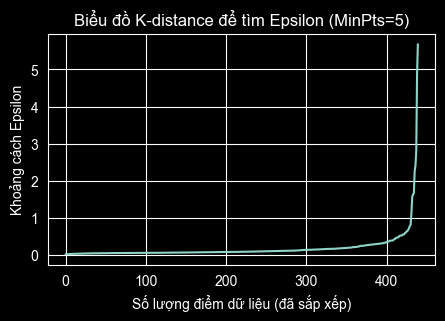

In [7]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5, algorithm='ball_tree')
neighbors_fit = neighbors.fit(x_scaled)
distances, indices = neighbors_fit.kneighbors(x_scaled)

distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(5, 3))
plt.plot(distances)
plt.title('Biểu đồ K-distance để tìm Epsilon (MinPts=5)')
plt.xlabel('Số lượng điểm dữ liệu (đã sắp xếp)')
plt.ylabel('Khoảng cách Epsilon')
plt.grid(True)
plt.show()

- Plot dữ liệu với thông tin các cụm

In [ ]:
from sklearn.cluster import DBSCAN
# nay tinh eps 0.5 - 0.7
eps = 0.5
min_pts = 5
dbscan = DBSCAN(eps=eps, min_samples=min_pts)
labels = dbscan.fit_predict(x_scaled)
df['Cluster'] = labels
print("Thống kê số điểm trong các cụm:")
print(df['Cluster'].value_counts())

Thống kê số điểm trong các cụm:
Cluster
 0    425
-1     15
Name: count, dtype: int64
